In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import streamlit as st
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier
from xgboost import XGBRegressor

df = pd.read_csv('cleaned_demand_data_2025.csv')
df

,timestamp,settlement_period,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,...,is_morning_peak,is_evening_peak,night,lagged_demand_30m,lagged_demand_1h,lagged_demand_24h,demand_rolling_mean_24h,renewable_gen,renewable_pct,net_demand
0,2025-01-01 00:00:00,1,21036,26215,19918,5405,6606,0,19270,0,...,False,False,True,NaN,NaN,NaN,19918.000000,5405,0.271363,14513
1,2025-01-01 00:30:00,2,21222,26063,20167,5358,6606,0,19270,0,...,False,False,True,19918.0,NaN,NaN,20042.500000,5358,0.265682,14809
2,2025-01-01 01:00:00,3,21385,25734,20328,5237,6606,0,19270,0,...,False,False,True,20167.0,19918.0,NaN,20137.666667,5237,0.257625,15091
3,2025-01-01 01:30:00,4,20473,24988,19460,5115,6606,0,19270,0,...,False,False,True,20328.0,20167.0,NaN,19968.250000,5115,0.262847,14345
4,2025-01-01 02:00:00,5,19634,24912,18654,5080,6606,0,19270,0,...,False,False,True,19460.0,20328.0,NaN,19705.400000,5080,0.272328,13574
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17515,2025-12-31 21:30:00,44,28633,30690,26868,3994,6606,0,22126,0,...,False,False,False,27896.0,29072.0,29056.0,28162.041667,3994,0.148653,22874
17516,2025-12-31 22:00:00,45,27381,30212,25722,4027,6606,0,22126,0,...,False,False,False,26868.0,27896.0,27917.0,28116.312500,4027,0.156559,21695
17517,2025-12-31 22:30:00,46,26563,29786,25049,4059,6606,0,22126,0,...,False,False,False,25722.0,26868.0,26598.0,28084.041667,4059,0.162042,20990
17518,2025-12-31 23:00:00,47,25481,30558,23955,4115,6606,0,22126,0,...,False,False,True,25049.0,25722.0,25493.0,28052.000000,4115,0.171780,19840


In [2]:
# generating descriptive stats

df.describe()

,settlement_period,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,pump_storage_pumping,...,quarter,weekday,week_number,lagged_demand_30m,lagged_demand_1h,lagged_demand_24h,demand_rolling_mean_24h,renewable_gen,renewable_pct,net_demand
count,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.0,17520.000000,17520.000000,17520.000000,17520.000000,...,17520.000000,17520.000000,17520.000000,17519.000000,17518.000000,17472.000000,17520.000000,17520.000000,17520.000000,17520.000000
mean,24.500228,26158.072603,28563.251256,23996.221975,1951.346233,6606.0,2130.222374,20813.171233,0.000228,172.601199,...,2.509932,2.996575,26.433676,23996.265712,23996.268067,23985.146635,23983.296043,4081.568607,0.188627,19914.653368
std,13.854190,6172.933513,6107.866569,5650.814832,1279.663725,0.0,3281.983315,840.120108,0.021368,318.518752,...,1.116796,1.997998,15.047826,5650.973150,5651.134439,5650.986663,4170.691059,3420.586426,0.192251,7290.961274
min,1.000000,12803.000000,15297.000000,12040.000000,125.000000,6606.0,0.000000,19270.000000,0.000000,0.000000,...,1.000000,0.000000,1.000000,12040.000000,12040.000000,12040.000000,15552.604167,130.000000,0.004044,-4436.000000
25%,12.750000,21432.750000,23897.750000,19638.000000,927.000000,6606.0,0.000000,20179.000000,0.000000,5.000000,...,2.000000,1.000000,13.000000,19638.000000,19638.000000,19628.500000,20656.541667,1464.000000,0.062087,15855.750000
50%,24.500000,24960.000000,27269.000000,22904.000000,1604.000000,6606.0,7.000000,20988.000000,0.000000,12.000000,...,3.000000,3.000000,26.000000,22904.000000,22904.000000,22895.000000,22938.906250,2927.500000,0.116494,19584.000000
75%,36.250000,29825.250000,32193.250000,27386.250000,2756.000000,6606.0,3483.000000,21510.000000,0.000000,170.000000,...,4.000000,5.000000,39.000000,27386.500000,27386.750000,27369.250000,27132.536458,5608.000000,0.237250,24460.250000
max,50.000000,45924.000000,47760.000000,41835.000000,5922.000000,6606.0,14046.000000,22126.000000,2.000000,1739.000000,...,4.000000,6.000000,52.000000,41835.000000,41835.000000,41835.000000,34687.208333,16894.000000,1.356076,40764.000000


In [3]:
# calculating memory usage for efficiency

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17520 entries, 0 to 17519
Data columns (total 42 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   timestamp                  17520 non-null  object 
 1   settlement_period          17520 non-null  int64  
 2   nd                         17520 non-null  int64  
 3   tsd                        17520 non-null  int64  
 4   england_wales_demand       17520 non-null  int64  
 5   embedded_wind_generation   17520 non-null  int64  
 6   embedded_wind_capacity     17520 non-null  int64  
 7   embedded_solar_generation  17520 non-null  int64  
 8   embedded_solar_capacity    17520 non-null  int64  
 9   non_bm_stor                17520 non-null  int64  
 10  pump_storage_pumping       17520 non-null  int64  
 11  scottish_transfer          17520 non-null  int64  
 12  ifa_flow                   17520 non-null  int64  
 13  ifa2_flow                  17520 non-null  int

In [4]:
# calculating mean, median, min, max, var and std for demand, solar and wind generation

pd.set_option('display.float_format', lambda x: f'{x:.2f}')
df['england_wales_demand'].agg(['mean', 'median', 'min', 'max', 'var', 'std'])

mean        23996.22
median      22904.00
min         12040.00
max         41835.00
var      31931708.27
std          5650.81
Name: england_wales_demand, dtype: float64

In [5]:
df['embedded_wind_generation'].agg(['mean', 'median', 'min', 'max', 'var', 'std'])

mean        1951.35
median      1604.00
min          125.00
max         5922.00
var      1637539.25
std         1279.66
Name: embedded_wind_generation, dtype: float64

In [6]:
df['embedded_solar_generation'].agg(['mean', 'median', 'min', 'max', 'var', 'std'])

mean         2130.22
median          7.00
min             0.00
max         14046.00
var      10771414.48
std          3281.98
Name: embedded_solar_generation, dtype: float64

In [7]:
# calculating 25th, 75th and 99th percentile results for demand, wind and solar generation

df['england_wales_demand'].quantile([0.25, 0.75, 0.99])

0.25   19638.00
0.75   27386.25
0.99   38136.67
Name: england_wales_demand, dtype: float64

In [8]:
df['embedded_wind_generation'].quantile([0.25, 0.75, 0.99])

0.25    927.00
0.75   2756.00
0.99   5425.00
Name: embedded_wind_generation, dtype: float64

In [9]:
df['embedded_solar_generation'].quantile([0.25, 0.75, 0.99])

0.25       0.00
0.75    3483.00
0.99   12250.86
Name: embedded_solar_generation, dtype: float64

level_0                        int64
index                          int64
timestamp                     object
settlement_period              int64
nd                             int64
tsd                            int64
england_wales_demand           int64
embedded_wind_generation       int64
embedded_wind_capacity         int64
embedded_solar_generation      int64
embedded_solar_capacity        int64
non_bm_stor                    int64
pump_storage_pumping           int64
scottish_transfer              int64
ifa_flow                       int64
ifa2_flow                      int64
britned_flow                   int64
moyle_flow                     int64
east_west_flow                 int64
nemo_flow                      int64
nsl_flow                       int64
eleclink_flow                  int64
viking_flow                    int64
greenlink_flow                 int64
day                            int64
month                          int64
year                           int64
h

In [ ]:
# converting timestamp to datetime format for time series exploration

df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

,timestamp,settlement_period,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,...,is_morning_peak,is_evening_peak,night,lagged_demand_30m,lagged_demand_1h,lagged_demand_24h,demand_rolling_mean_24h,renewable_gen,renewable_pct,net_demand
0,2025-01-01 00:00:00,1,21036,26215,19918,5405,6606,0,19270,0,...,False,False,True,NaN,NaN,NaN,19918.00,5405,0.27,14513
1,2025-01-01 00:30:00,2,21222,26063,20167,5358,6606,0,19270,0,...,False,False,True,19918.00,NaN,NaN,20042.50,5358,0.27,14809
2,2025-01-01 01:00:00,3,21385,25734,20328,5237,6606,0,19270,0,...,False,False,True,20167.00,19918.00,NaN,20137.67,5237,0.26,15091
3,2025-01-01 01:30:00,4,20473,24988,19460,5115,6606,0,19270,0,...,False,False,True,20328.00,20167.00,NaN,19968.25,5115,0.26,14345
4,2025-01-01 02:00:00,5,19634,24912,18654,5080,6606,0,19270,0,...,False,False,True,19460.00,20328.00,NaN,19705.40,5080,0.27,13574


,timestamp,settlement_period,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,...,is_morning_peak,is_evening_peak,night,lagged_demand_30m,lagged_demand_1h,lagged_demand_24h,demand_rolling_mean_24h,renewable_gen,renewable_pct,net_demand
0,2025-01-01 00:00:00,1,21036,26215,19918,5405,6606,0,19270,0,...,False,False,True,NaN,NaN,NaN,19918.00,5405,0.27,14513
1,2025-01-01 00:30:00,2,21222,26063,20167,5358,6606,0,19270,0,...,False,False,True,19918.00,NaN,NaN,20042.50,5358,0.27,14809
2,2025-01-01 01:00:00,3,21385,25734,20328,5237,6606,0,19270,0,...,False,False,True,20167.00,19918.00,NaN,20137.67,5237,0.26,15091
3,2025-01-01 01:30:00,4,20473,24988,19460,5115,6606,0,19270,0,...,False,False,True,20328.00,20167.00,NaN,19968.25,5115,0.26,14345
4,2025-01-01 02:00:00,5,19634,24912,18654,5080,6606,0,19270,0,...,False,False,True,19460.00,20328.00,NaN,19705.40,5080,0.27,13574


timestamp                    datetime64[ns]
settlement_period                     int64
nd                                    int64
tsd                                   int64
england_wales_demand                  int64
embedded_wind_generation              int64
embedded_wind_capacity                int64
embedded_solar_generation             int64
embedded_solar_capacity               int64
non_bm_stor                           int64
pump_storage_pumping                  int64
scottish_transfer                     int64
ifa_flow                              int64
ifa2_flow                             int64
britned_flow                          int64
moyle_flow                            int64
east_west_flow                        int64
nemo_flow                             int64
nsl_flow                              int64
eleclink_flow                         int64
viking_flow                           int64
greenlink_flow                        int64
day                             

,settlement_period,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,pump_storage_pumping,...,is_morning_peak,is_evening_peak,night,lagged_demand_30m,lagged_demand_1h,lagged_demand_24h,demand_rolling_mean_24h,renewable_gen,renewable_pct,net_demand
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-01-01 00:00:00,1,21036,26215,19918,5405,6606,0,19270,0,859,...,False,False,True,NaN,NaN,NaN,19918.00,5405,0.27,14513
2025-01-01 00:30:00,2,21222,26063,20167,5358,6606,0,19270,0,735,...,False,False,True,19918.00,NaN,NaN,20042.50,5358,0.27,14809
2025-01-01 01:00:00,3,21385,25734,20328,5237,6606,0,19270,0,691,...,False,False,True,20167.00,19918.00,NaN,20137.67,5237,0.26,15091
2025-01-01 01:30:00,4,20473,24988,19460,5115,6606,0,19270,0,931,...,False,False,True,20328.00,20167.00,NaN,19968.25,5115,0.26,14345
2025-01-01 02:00:00,5,19634,24912,18654,5080,6606,0,19270,0,854,...,False,False,True,19460.00,20328.00,NaN,19705.40,5080,0.27,13574


KeyError: 'timestamp'

In [34]:
df.head()

,settlement_period,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,pump_storage_pumping,...,is_morning_peak,is_evening_peak,night,lagged_demand_30m,lagged_demand_1h,lagged_demand_24h,demand_rolling_mean_24h,renewable_gen,renewable_pct,net_demand
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-01-01 00:00:00,1,21036,26215,19918,5405,6606,0,19270,0,859,...,False,False,True,NaN,NaN,NaN,19918.00,5405,0.27,14513
2025-01-01 00:30:00,2,21222,26063,20167,5358,6606,0,19270,0,735,...,False,False,True,19918.00,NaN,NaN,20042.50,5358,0.27,14809
2025-01-01 01:00:00,3,21385,25734,20328,5237,6606,0,19270,0,691,...,False,False,True,20167.00,19918.00,NaN,20137.67,5237,0.26,15091
2025-01-01 01:30:00,4,20473,24988,19460,5115,6606,0,19270,0,931,...,False,False,True,20328.00,20167.00,NaN,19968.25,5115,0.26,14345
2025-01-01 02:00:00,5,19634,24912,18654,5080,6606,0,19270,0,854,...,False,False,True,19460.00,20328.00,NaN,19705.40,5080,0.27,13574


Text(0.5, 1.0, 'Hourly View of Average England Wales Demand')

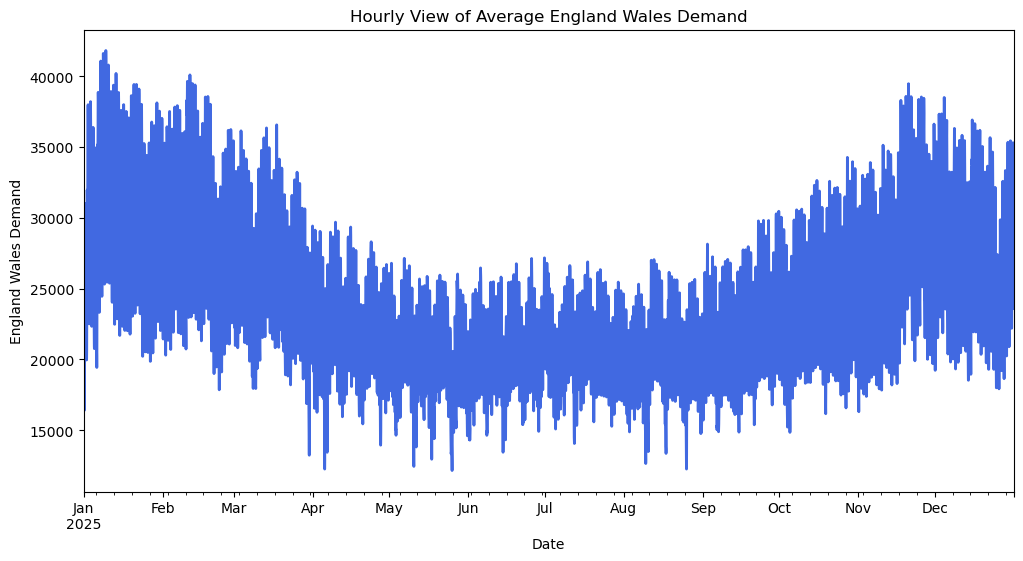

In [46]:
# plotting hourly average demand

plt.figure(figsize=[12,6])

df.resample('h')['england_wales_demand'].mean().plot(linewidth=2, color='royalblue')

plt.xlabel('Date')
plt.ylabel('England Wales Demand')
plt.title('Hourly View of Average England Wales Demand')

Text(0.5, 1.0, 'Daily View of Average England Wales Demand')

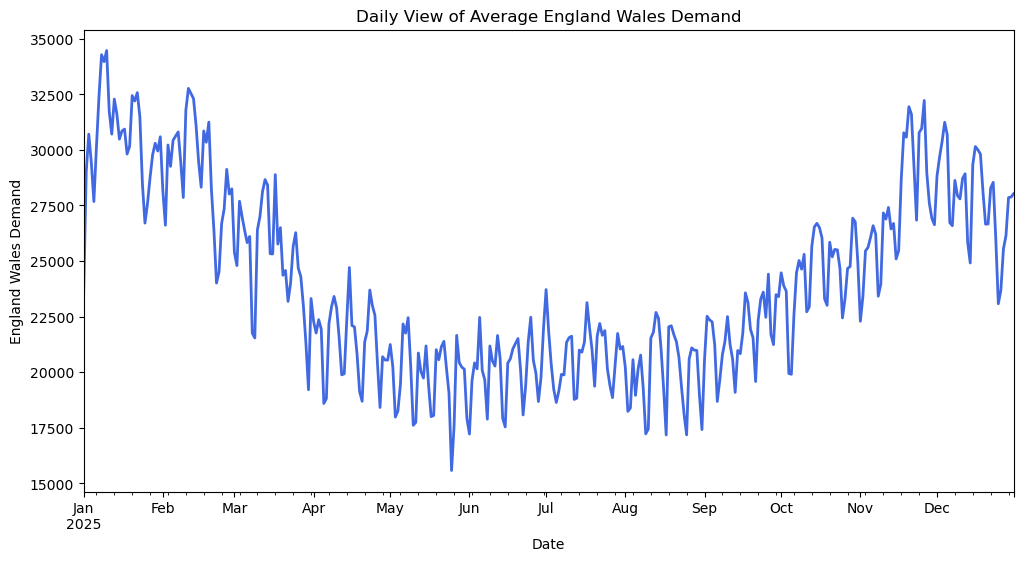

In [39]:
# plotting daily average demand

plt.figure(figsize=[12,6])

df.resample('D')['england_wales_demand'].mean().plot(linewidth=2, color='royalblue')

plt.xlabel('Date')
plt.ylabel('England Wales Demand')
plt.title('Daily View of Average England Wales Demand')

Text(0.5, 1.0, 'Weekly View of Average England Wales Demand')

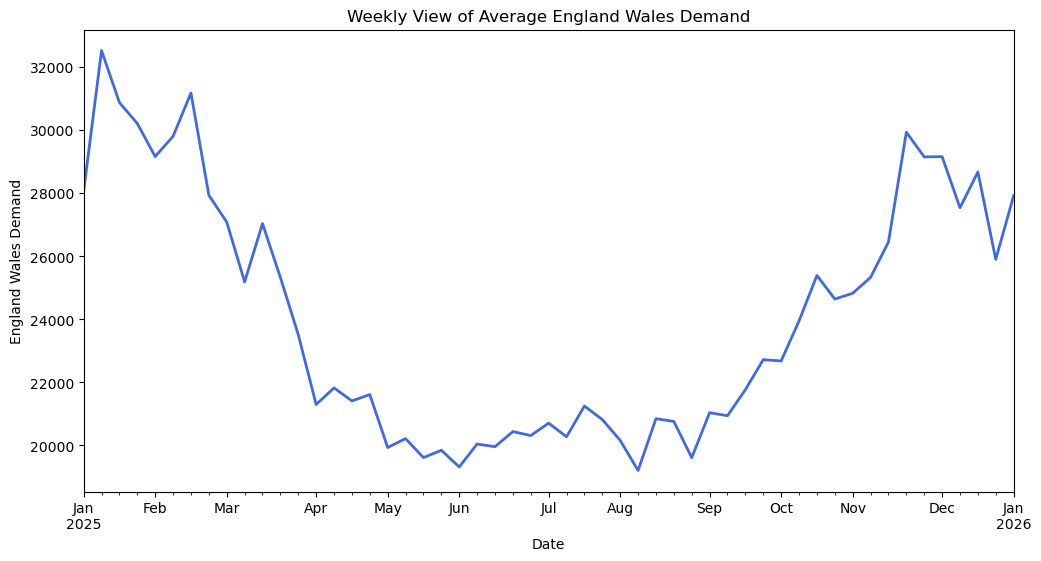

In [40]:
# plotting weekly average demand

plt.figure(figsize=[12,6])

df.resample('W')['england_wales_demand'].mean().plot(linewidth=2, color='royalblue')

plt.xlabel('Date')
plt.ylabel('England Wales Demand')
plt.title('Weekly View of Average England Wales Demand')

Text(0.5, 1.0, 'Monthly View of Average England Wales Demand')

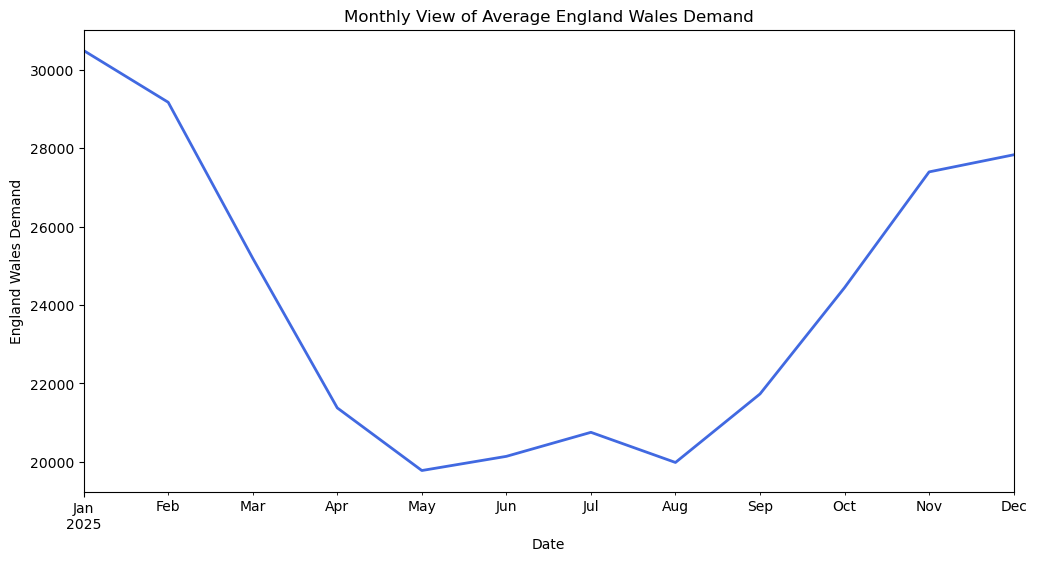

In [43]:
# plotting monthly average demand

plt.figure(figsize=[12,6])

df.resample('ME')['england_wales_demand'].mean().plot(linewidth=2, color='royalblue')

plt.xlabel('Date')
plt.ylabel('England Wales Demand')
plt.title('Monthly View of Average England Wales Demand')

Text(0.5, 1.0, 'Hourly View of Average Embedded Wind Generation')

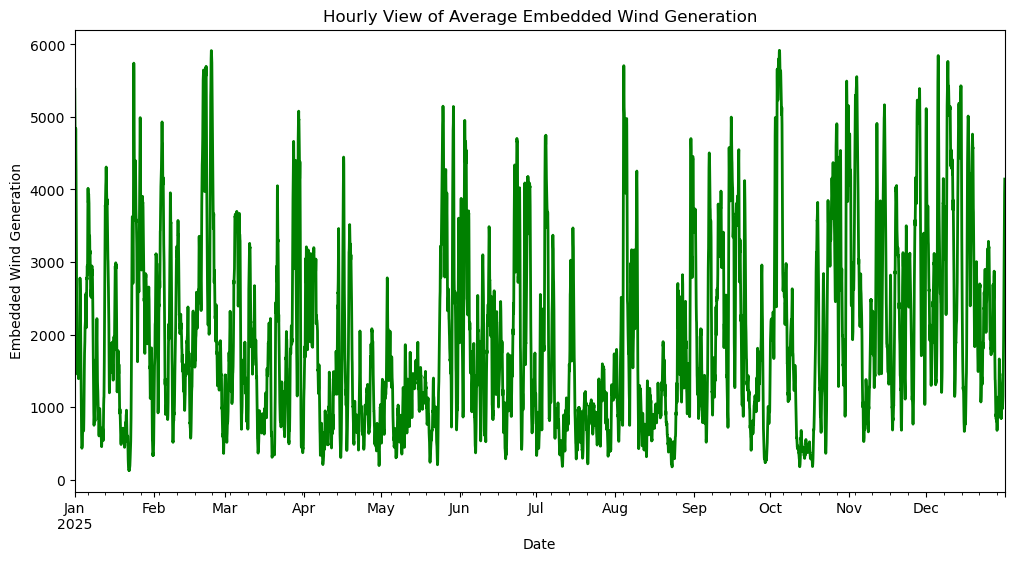

In [45]:
# plotting hourly average wind generation

plt.figure(figsize=[12,6])

df.resample('h')['embedded_wind_generation'].mean().plot(linewidth=2, color='green')

plt.xlabel('Date')
plt.ylabel('Embedded Wind Generation')
plt.title('Hourly View of Average Embedded Wind Generation')

Text(0.5, 1.0, 'Daily View of Average Embedded Wind Generation')

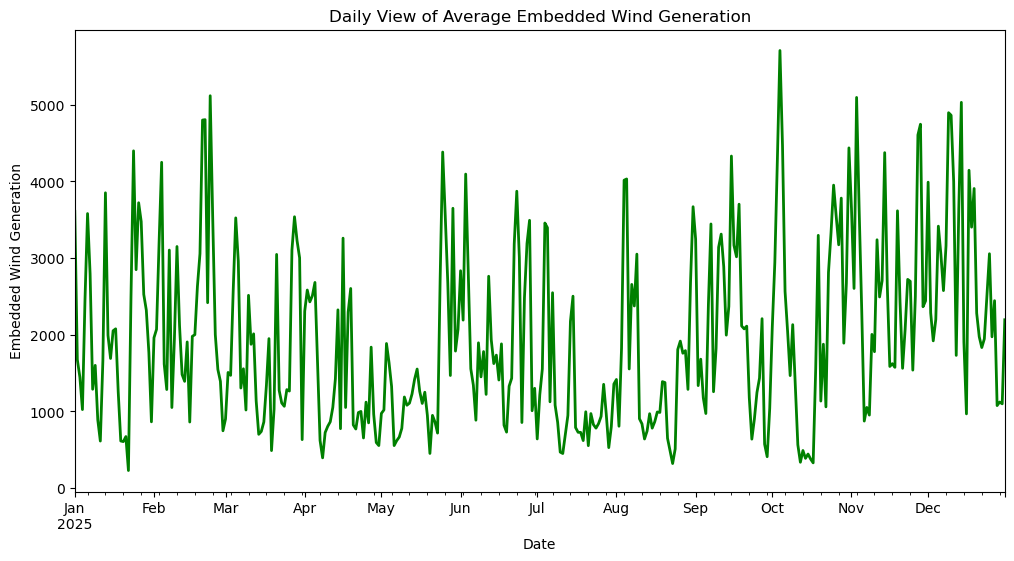

In [47]:
# plotting daily average wind generation

plt.figure(figsize=[12,6])

df.resample('D')['embedded_wind_generation'].mean().plot(linewidth=2, color='green')

plt.xlabel('Date')
plt.ylabel('Embedded Wind Generation')
plt.title('Daily View of Average Embedded Wind Generation')

Text(0.5, 1.0, 'Weekly View of Average Embedded Wind Generation')

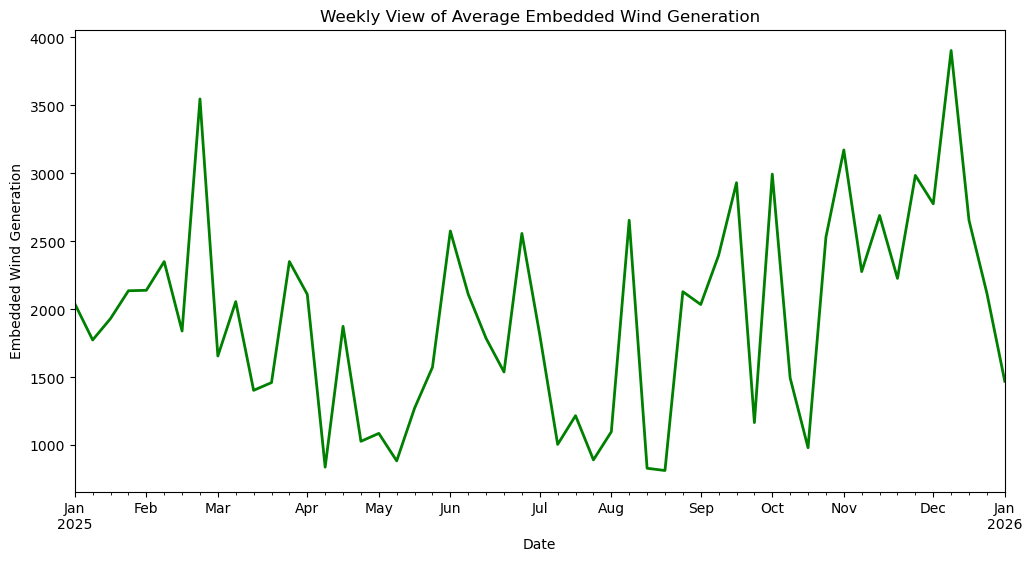

In [48]:
# plotting weekly average wind generation

plt.figure(figsize=[12,6])

df.resample('W')['embedded_wind_generation'].mean().plot(linewidth=2, color='green')

plt.xlabel('Date')
plt.ylabel('Embedded Wind Generation')
plt.title('Weekly View of Average Embedded Wind Generation')

Text(0.5, 1.0, 'Monthly View of Average Embedded Wind Generation')

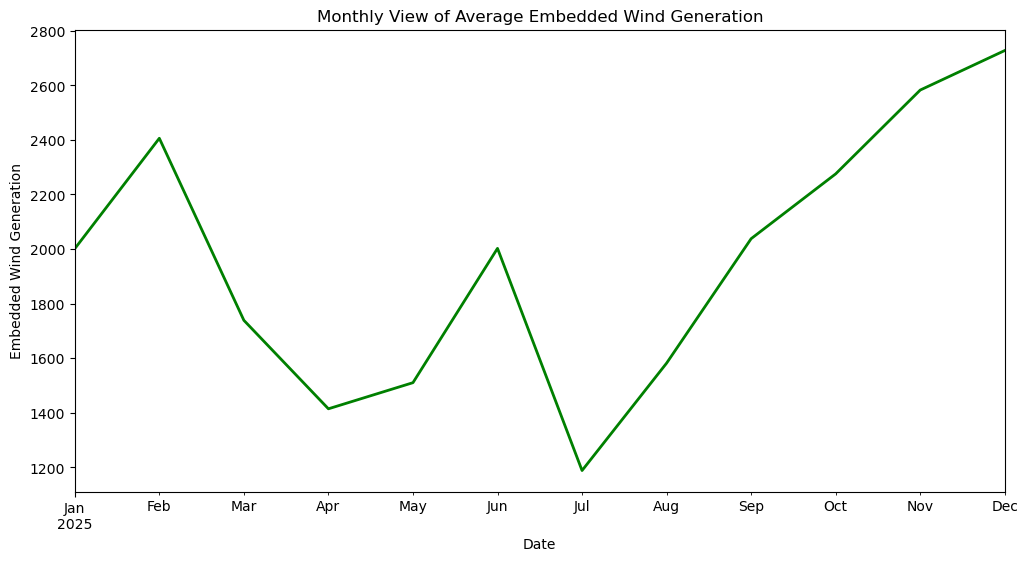

In [49]:
# plotting monthly average wind generation

plt.figure(figsize=[12,6])

df.resample('ME')['embedded_wind_generation'].mean().plot(linewidth=2, color='green')

plt.xlabel('Date')
plt.ylabel('Embedded Wind Generation')
plt.title('Monthly View of Average Embedded Wind Generation')

Text(0.5, 1.0, 'Hourly View of Average Embedded Solar Generation')

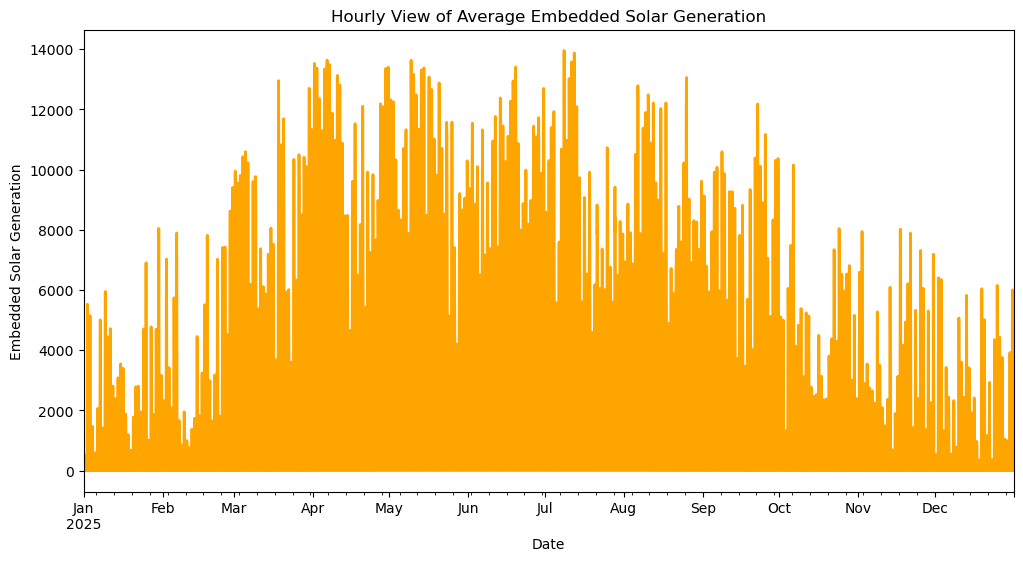

In [50]:
# plotting hourly average solar generation

plt.figure(figsize=[12,6])

df.resample('h')['embedded_solar_generation'].mean().plot(linewidth=2, color='orange')

plt.xlabel('Date')
plt.ylabel('Embedded Solar Generation')
plt.title('Hourly View of Average Embedded Solar Generation')

Text(0.5, 1.0, 'Daily View of Average Embedded Solar Generation')

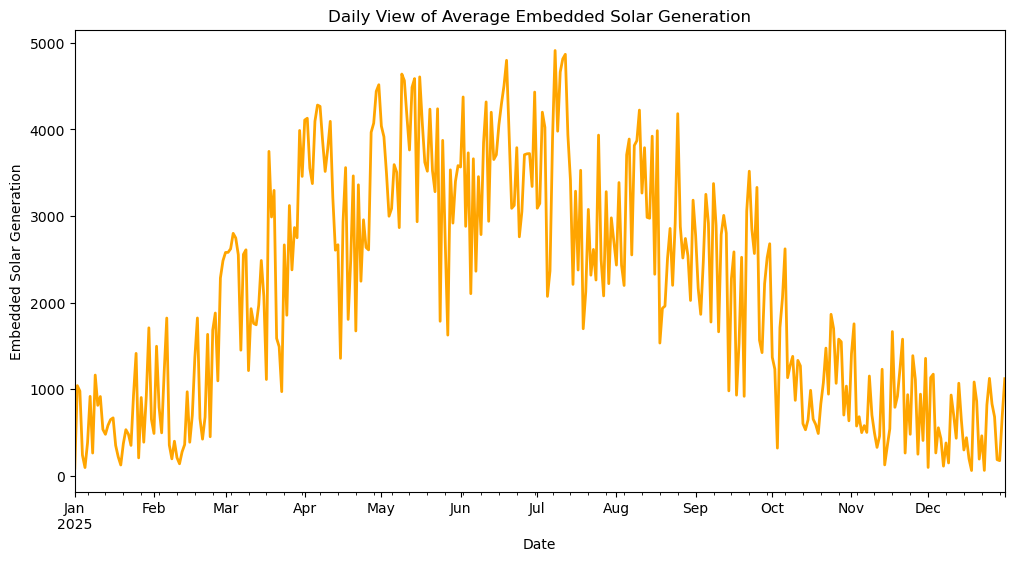

In [51]:
# plotting daily average solar generation

plt.figure(figsize=[12,6])

df.resample('D')['embedded_solar_generation'].mean().plot(linewidth=2, color='orange')

plt.xlabel('Date')
plt.ylabel('Embedded Solar Generation')
plt.title('Daily View of Average Embedded Solar Generation')

Text(0.5, 1.0, 'Weekly View of Average Embedded Solar Generation')

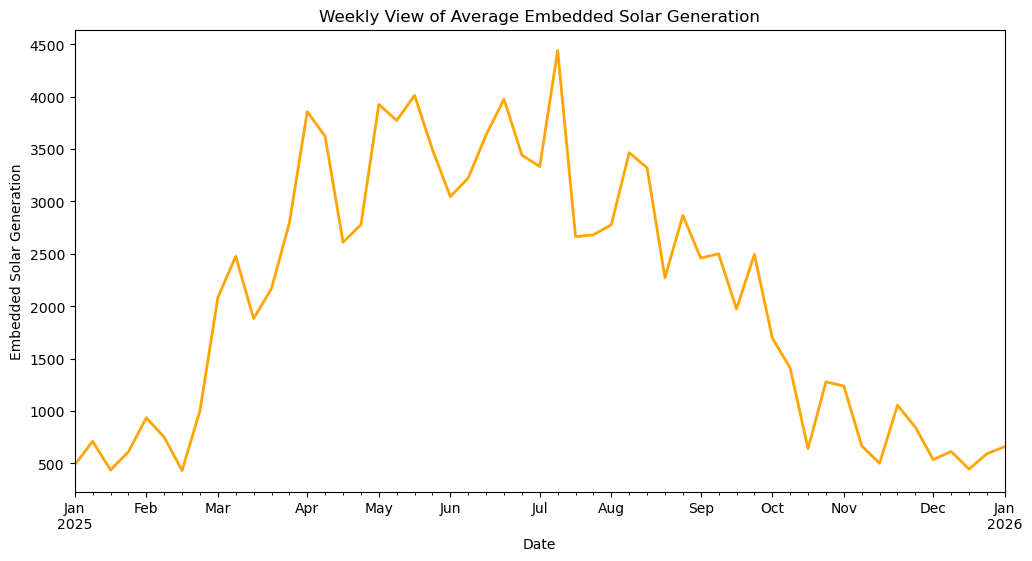

In [52]:
# plotting weekly average solar generation

plt.figure(figsize=[12,6])

df.resample('W')['embedded_solar_generation'].mean().plot(linewidth=2, color='orange')

plt.xlabel('Date')
plt.ylabel('Embedded Solar Generation')
plt.title('Weekly View of Average Embedded Solar Generation')

Text(0.5, 1.0, 'Monthly View of Average Embedded Solar Generation')

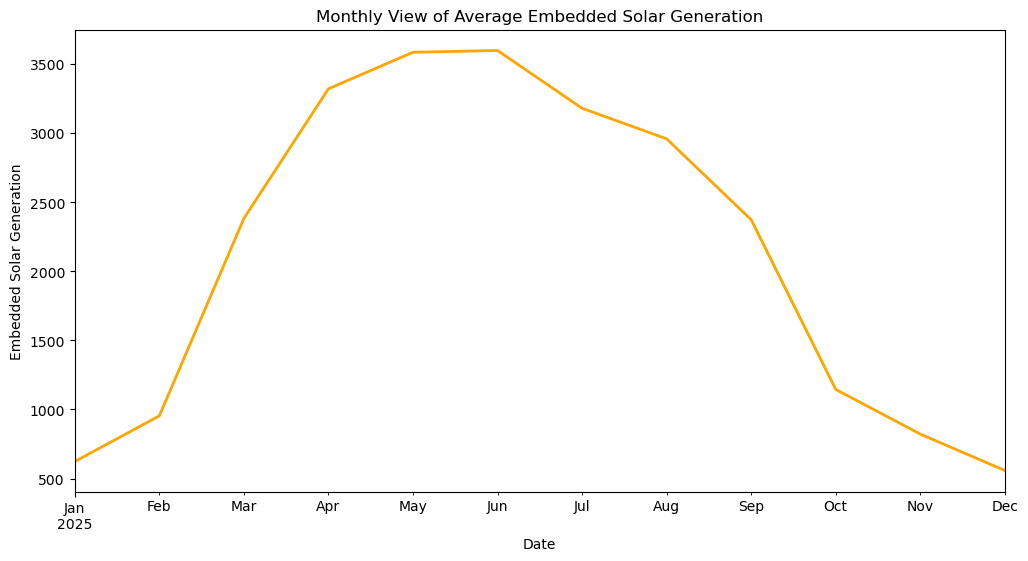

In [53]:
# plotting monthly average solar generation

plt.figure(figsize=[12,6])

df.resample('ME')['embedded_solar_generation'].mean().plot(linewidth=2, color='orange')

plt.xlabel('Date')
plt.ylabel('Embedded Solar Generation')
plt.title('Monthly View of Average Embedded Solar Generation')

Text(0, 0.5, 'Average Demand By Settlement Period')

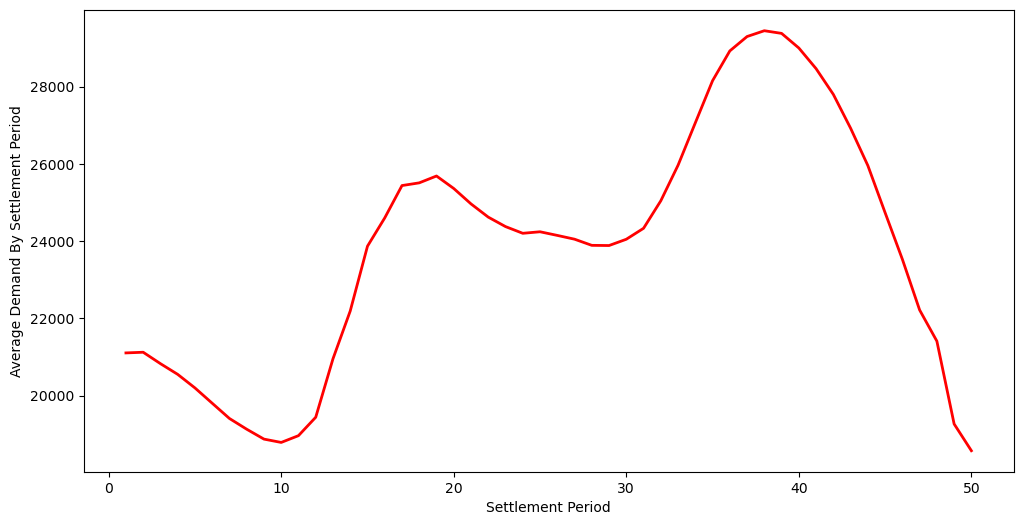

In [54]:
# plotting average demand by settlement period

plt.figure(figsize=[12,6])

df.groupby('settlement_period')['england_wales_demand'].mean().plot(linewidth=2, color='red')

plt.xlabel('Settlement Period')
plt.ylabel('England Wales Demand')
plt.ylabel('Average Demand By Settlement Period')

Text(0.5, 1.0, 'Average Demand On Weekend vs Weekdays')

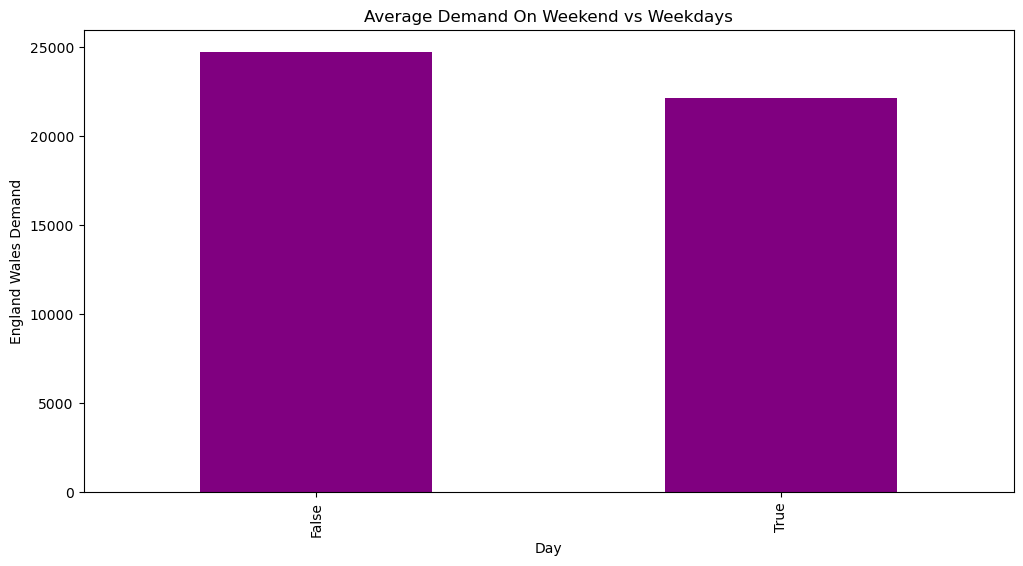

In [57]:
# plotting average demand on weekend vs weekday

plt.figure(figsize=[12,6])

df.groupby('is_weekend')['england_wales_demand'].mean().plot(kind='bar', color='purple')

plt.xlabel('Day')
plt.ylabel('England Wales Demand')
plt.title('Average Demand On Weekend vs Weekdays')

Text(0.5, 1.0, 'Average Demand Per Quarter')

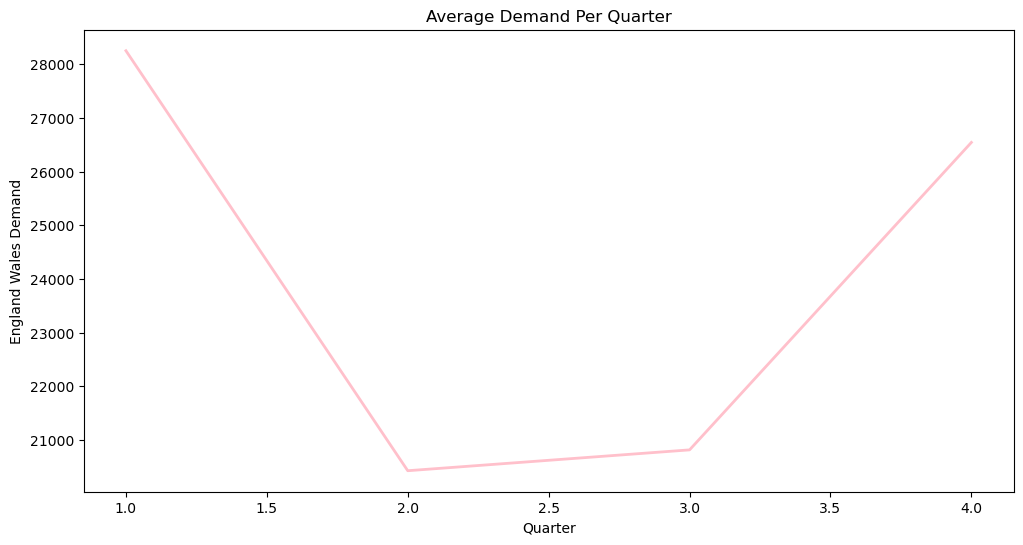

In [61]:
# comparing demand, solar and wind generation by season

plt.figure(figsize=[12,6])

df.groupby('quarter')['england_wales_demand'].mean().plot(linewidth=2, color='pink')

plt.xlabel('Quarter')
plt.ylabel('England Wales Demand')
plt.title('Average Demand Per Quarter')

Text(0.5, 1.0, 'Average Embedded Wind Generation Per Quarter')

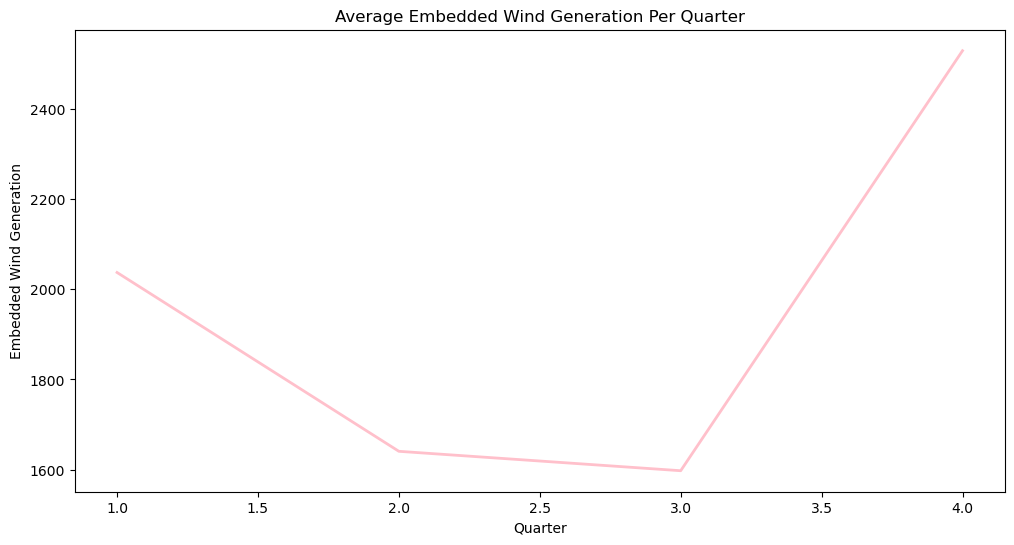

In [62]:

plt.figure(figsize=[12,6])

df.groupby('quarter')['embedded_wind_generation'].mean().plot(linewidth=2, color='pink')

plt.xlabel('Quarter')
plt.ylabel('Embedded Wind Generation')
plt.title('Average Embedded Wind Generation Per Quarter')

Text(0.5, 1.0, 'Average Embedded Solar Generation Per Quarter')

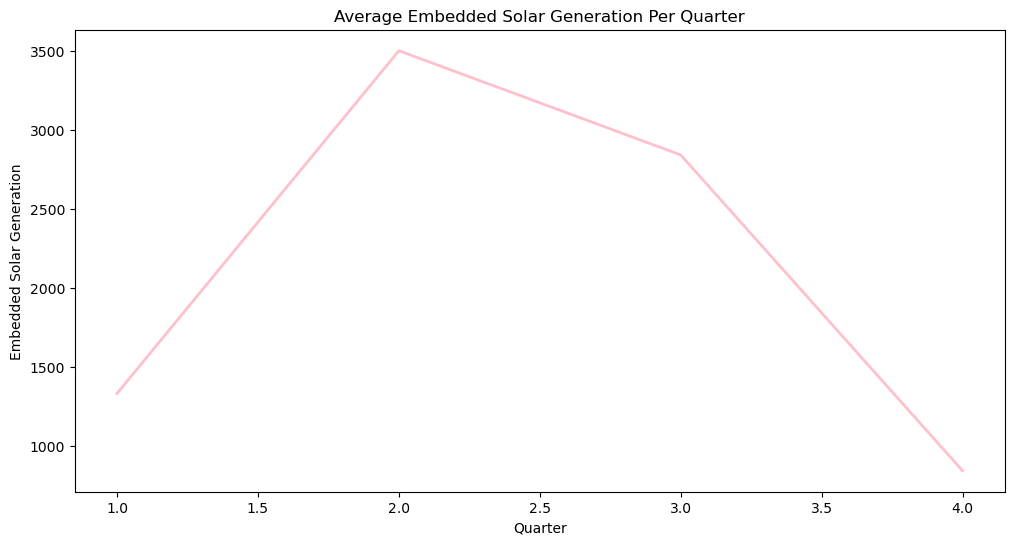

In [63]:

plt.figure(figsize=[12,6])

df.groupby('quarter')['embedded_solar_generation'].mean().plot(linewidth=2, color='pink')

plt.xlabel('Quarter')
plt.ylabel('Embedded Solar Generation')
plt.title('Average Embedded Solar Generation Per Quarter')

In [64]:
# identifying the top 5 highest demand days

df.reset_index('timestamp', inplace=True)

df.sort_values('england_wales_demand', ascending=False)[['timestamp', 'england_wales_demand']].head(5)

,timestamp,england_wales_demand
418,2025-01-09 17:00:00,41835
419,2025-01-09 17:30:00,41811
371,2025-01-08 17:30:00,41620
370,2025-01-08 17:00:00,41614
420,2025-01-09 18:00:00,41479


In [67]:
# identifying the top 5 lowest demand days

df.sort_values('england_wales_demand', ascending=True)[['timestamp', 'england_wales_demand']].head(5)

,timestamp,england_wales_demand
6939,2025-05-25 14:30:00,12040
11354,2025-08-25 14:00:00,12093
4538,2025-04-05 14:00:00,12119
6938,2025-05-25 14:00:00,12276
6218,2025-05-10 14:00:00,12355


In [68]:
# now save the csv file

df.to_csv('analysed_demand_data_2025.csv')
print('CSV saved successfully.')

CSV saved successfully.
